In [1]:
import numpy as np
import xtrack as xt
import xobjects as xo
import xpart as xp
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy import constants 
import json

with open('sps.json', 'r') as f:
    line = xt.Line.from_dict(json.load(f))  
# particle_ref=line.particle_ref

line.build_tracker()
#line.freeze_longitudinal()
# line.optimize_for_tracking()

twiss=line.twiss()

clight=constants.speed_of_light
circumference = line.get_length()


#%%
###################
# Linear Transfer #
###################

qx=twiss['qx']
qy=twiss['qy']
dqx=twiss['dqx']
dqy=twiss['dqy']
circumference=twiss['s'][-1]
# beta_x=twiss['betx'][-1]
# beta_y=twiss['bety'][-1]

qs=twiss['qs']
bets=twiss['bets0']
voltage_rf=7*1e6
frequency=201.8251348335775*1e6
lag_rf=180
momentum_compaction_factor=twiss['momentum_compaction_factor']
slip_factor=twiss['slip_factor']

# qs=0.0131
# bets=0.063/2e-4

#at interaction points: #from https://anaconda.org/petrenko/li_like_ca_in_sps/notebook
beta_x  =  54.614389 # m
beta_y  =  44.332517 # m
alpha_x = -1.535235
alpha_y =  1.314101

Dx  =  2.444732 # m
Dpx =  0.097522

Dy  =  0.0 # m
Dpy =  0.0

#index of gamma factory along SPS line: 16675

arc = xt.LineSegmentMap(
        qx=qx, qy=qy,
        dqx=0, dqy=0,
        length=circumference,
        alfx=alpha_x,
        alfy=alpha_y,
        betx=beta_x,
        bety=beta_y,
        
        dx=Dx,
        dpx=Dpx,
        dy=Dy,
        dpy=Dpy,
        # qs=qs,
        # bets=bets,
        voltage_rf=voltage_rf,
        lag_rf=lag_rf,
        frequency_rf=frequency,
        momentum_compaction_factor=momentum_compaction_factor,
        longitudinal_mode = 'nonlinear'
        )


Xcoll not installed
Loading line from dict: 100%|██████████| 38786/38786 [00:02<00:00, 18673.63it/s]


Done loading line from dict.           
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


In [2]:
from ion_properties import lead,calcium,xenon,xenon2nd


In [3]:
calcium.laser_x

-0.0015771812080536912

In [ ]:
for ion in [calcium]:# Ion properties:
        q0 = ion.q0
        mass0 = ion.mass0

        gamma0= ion.gamma_cooling
        beta0= ion.beta_rel      
        p0c = mass0*gamma0*beta0 #eV/c

        bunch_intensity = ion.bunch_intensity

        particle_ref = xp.Particles(p0c=p0c, mass0=mass0, q0=q0, gamma0=gamma0)

        line.particle_ref=particle_ref

        nemitt = 1.5e-6 # m*rad (normalized emittance)
        sigma_z = ion.bunch_length
        #sigma_z = 0.063

        # emittance=nemitt/(beta*gamma)
        
        num_particles=int(1e3)

        line_arc=xt.Line(
                elements=[arc])
        line_arc.build_tracker()

        particles = xp.generate_matched_gaussian_bunch(
                num_particles=num_particles,
                total_intensity_particles=bunch_intensity,
                nemitt_x=nemitt, nemitt_y=nemitt, sigma_z=sigma_z,
                particle_ref=particle_ref,
                line=line_arc,
                )
        particles._init_random_number_generator()
        
        particles0=particles.copy()

        # sigma_dp=2e-4  
        sigma_dp=np.std(particles.delta)
        print('sigma_dp',sigma_dp*1e4)
        sigma_dp=2e-4 
        ##################
        # Laser Cooler #
        ##################

        #laser-ion beam collision angle
        theta_l = 2.6*np.pi/180 # rad
        nx = 0; ny = -np.sin(theta_l); nz = -np.cos(theta_l)

        # Ion excitation energy:
        ion_excited_lifetime=ion.excited_lifetime
        hw0 = ion.hw0 # eV
        hc=constants.hbar*clight/constants.e # eV*m (ħc)
        lambda_0 = 2*np.pi*hc/hw0 # m -- ion excitation wavelength

        lambda_l = ion.lambda_l


        # Shift laser wavelength for fast longitudinal cooling:
        #lambda_l = lambda_l*(1+1*sigma_dp) # m

        laser_frequency = clight/lambda_l # Hz
        sigma_w = 2*np.pi*laser_frequency*sigma_dp
        #sigma_w = 2*np.pi*laser_frequency*sigma_dp/2 # for fast longitudinal cooling

        sigma_t = 1/sigma_w # sec -- Fourier-limited laser pulse
        print('Laser pulse duration sigma_t = %.2f ps' % (sigma_t/1e-12))
        print('Laser wavelength = %.2f nm' % (lambda_l/1e-9))

        laser_waist_radius = 1.3e-3 #m
        laser_energy = 5e-3
        #laser_energy = ion.pulse_energy   
        print('Laser pulse duration sigma_t = %.2f ps' % (sigma_t/1e-12))
        
        laser_x = ion.laser_x

        GF_IP = xt.PulsedLaser(
                        laser_x=laser_x,
                        laser_y=0,
                        laser_z=0,
                        
                        laser_direction_nx = 0,
                        laser_direction_ny = ny,
                        laser_direction_nz = nz,
                        laser_energy         = laser_energy, # J
                        laser_duration_sigma = sigma_t, # sec
                        laser_wavelength = lambda_l, # m
                        laser_waist_radius = laser_waist_radius, # m
                        laser_waist_shift = 0, # m
                        ion_excitation_energy = hw0, # eV
                        ion_excited_lifetime  = ion_excited_lifetime, # sec                   
                        )

        # simulation parameters: simulate 10 s of cooling, and take data once every 100 ms
        max_time_s = 1
        int_time_s = 0.01

        T_per_turn = circumference/(clight*beta0)

        # max_time_s = 5*T_per_turn
        # int_time_s = T_per_turn

        
        num_turns = int(max_time_s/T_per_turn)
        save_interval = int(int_time_s/T_per_turn)


        # create a monitor object, to reduce holded data
        monitor = xt.ParticlesMonitor(start_at_turn=0, stop_at_turn=1,
                                n_repetitions=int(num_turns/save_interval),
                                repetition_period=save_interval,
                                num_particles=num_particles)
                                    
        line = xt.Line(
                elements=[monitor,GF_IP,arc])
        
        # line = xt.Line(
        #         elements=[monitor,arc])

        context = xo.ContextCpu(omp_num_threads=4)
        line.build_tracker(_context=context)

        line.track(particles, num_turns=num_turns,
                turn_by_turn_monitor=False,with_progress=True)

        # extract relevant values
        x = monitor.x[:,:,0]
        px = monitor.px[:,:,0]
        y = monitor.y[:,:,0]
        py = monitor.py[:,:,0]
        delta = monitor.delta[:,:,0]
        zeta = monitor.zeta[:,:,0]
        state = monitor.state[:,:,0]
        time = monitor.at_turn[:, 0, 0] * T_per_turn

        gamma_x=(1+alpha_x**2)/beta_x
        gamma_y=(1+alpha_y**2)/beta_y

        action_x = (gamma_x*(x-Dx*delta)**2 + 2*alpha_x*(x-Dx*delta)*(px-Dpx*delta)+ beta_x*(px-Dpx*delta)**2)
        action_y = (gamma_y*(y-Dy*delta)**2 + 2*alpha_y*(y-Dy*delta)*(py-Dpy*delta)+ beta_y*(py-Dpy*delta)**2)

        emittance_x_twiss=np.mean(action_x,axis=1)*beta0*gamma0/2
        rms_dp_p=np.std(delta,axis=1)

        
        np.savez(f'results/alexey.npz', x=x, px=px, y=y, py=py, zeta=zeta, delta=delta,
                action_x=action_x,action_y=action_y,emittance_x=emittance_x_twiss,state=state, time=time,s_per_turn=T_per_turn)

Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
*** Maximum RMS bunch length 0.23411645756327412m.


/home/pkruyt/miniforge3/envs/xsuite_laser2025/lib/python3.10/site-packages/scipy/integrate/_quadpack_py.py:1260: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,


... distance to target bunch length: -9.3234e-02
... distance to target bunch length: 1.3265e-01
... distance to target bunch length: 9.6426e-02
... distance to target bunch length: 5.5382e-03
... distance to target bunch length: -6.2242e-04
... distance to target bunch length: -5.3543e-06
... distance to target bunch length: 8.6936e-11
... distance to target bunch length: -5.2310e-07
--> Bunch length: 0.09500000008693617
--> Emittance: 0.3668607000812198
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
sigma_dp 2.1499802280671965
Laser pulse duration sigma_t = 2.04 ps
Laser wavelength = 768.00 nm
Laser pulse duration sigma_t = 2.04 ps
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


Tracking: 100%|██████████| 43400/43400 [00:03<00:00, 12970.83it/s]


In [5]:
slip_factor

np.float64(0.0017929644024200376)

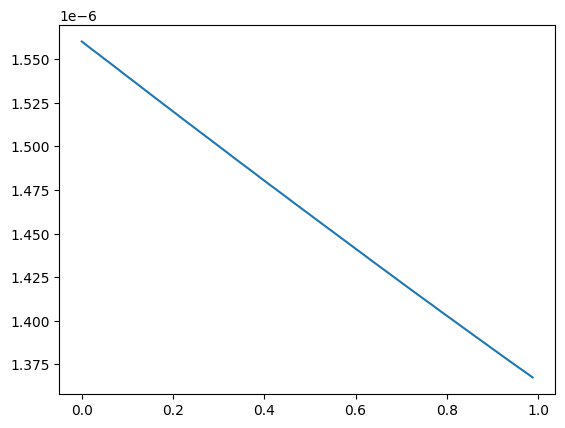

In [6]:
plt.figure()
plt.plot(time,emittance_x_twiss)
plt.show()

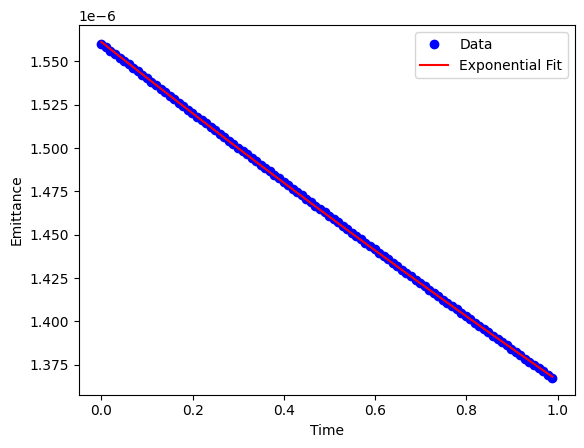

Fitted parameters:
A = 1.5612554335431071e-06
tau = 7.483997940981569


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Define the exponential decay function
def exp_decay(t, A, tau ):
    return A * np.exp(-t / tau)

A0 = emittance_x_twiss[0]
tau0 = (time[-1] - time[0]) / 5.0
C0 = emittance_x_twiss[-1]
initial_guess = (A0, tau0)

popt, pcov = curve_fit(exp_decay, time, emittance_x_twiss, p0=initial_guess)

time_fit = np.linspace(np.min(time), np.max(time), 100)
emittance_fit = exp_decay(time_fit, *popt)

# Plot the original data and the fitted exponential decay curve
plt.figure()
plt.plot(time, emittance_x_twiss, 'bo', label='Data')
plt.plot(time_fit, emittance_fit, 'r-', label='Exponential Fit')
plt.xlabel('Time')
plt.ylabel('Emittance')
plt.legend()
plt.show()

# Print the fitted parameters
print("Fitted parameters:")
print("A =", popt[0])
print("tau =", popt[1])



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Define the exponential decay function
def exp_decay(t, A, tau ):
    return A * np.exp(-t / tau)

A0 = emittance_x_twiss[0]
tau0 = (time[-1] - time[0]) / 5.0
C0 = emittance_x_twiss[-1]
initial_guess = (A0, tau0)

popt, pcov = curve_fit(exp_decay, time, emittance_x_twiss, p0=initial_guess)

time_fit = np.linspace(np.min(time), np.max(time), 100)
emittance_fit = exp_decay(time_fit, *popt)

# Plot the original data and the fitted exponential decay curve
plt.figure()
plt.plot(time, emittance_x_twiss, 'bo', label='Data')
plt.plot(time_fit, emittance_fit, 'r-', label='Exponential Fit')
plt.xlabel('Time')
plt.ylabel('Emittance')
plt.legend()
plt.show()

# Print the fitted parameters
print("Fitted parameters:")
print("A =", popt[0])
print("tau =", popt[1])



/tmp/pkruyt/ipykernel_461945/958925726.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


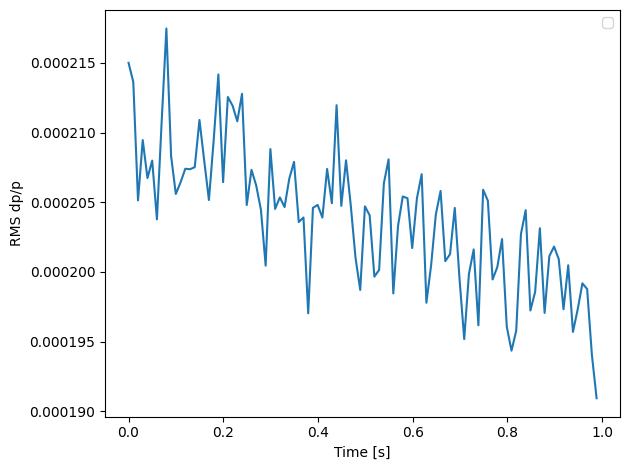

In [8]:
excited0=state[1,:]==2
fraction_excitation=sum(excited0)/len(excited0)
rms_dp_p = np.std(delta, axis=1)


plt.figure()
plt.plot(time, rms_dp_p)

plt.xlabel(r'Time [s]')
plt.ylabel(r'RMS dp/p')
plt.legend()
plt.tight_layout()
# plt.savefig('Transverse_laser_cooling_rates.png', dpi=300)
plt.show()

In [9]:
xenon.N_a/1e8

1.99040147

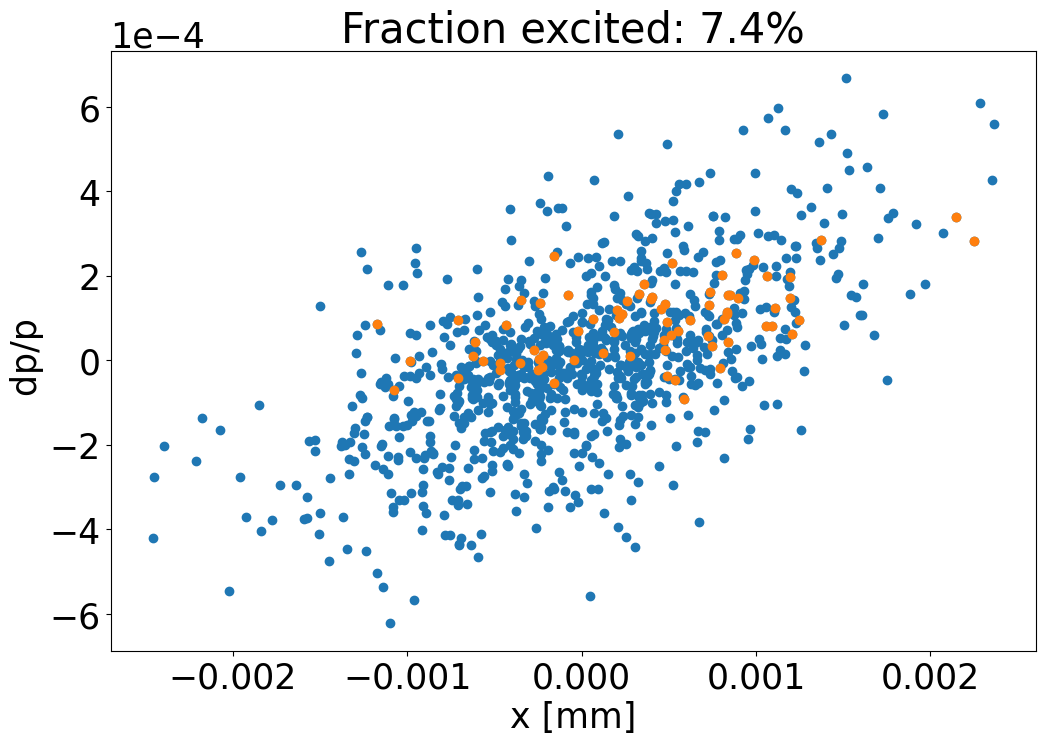

In [10]:
turn=-1
excited=state==2
excited0=excited[turn,:]
fraction_excitation0 = sum(excited0)/len(excited0)*100


plt.figure(figsize=(12, 8))
plt.rcParams.update({'font.size': 25})
plt.title(f'Fraction excited: {round(fraction_excitation0, 1)}%')

#plt.axvline(laser_x,color='red')
# plt.axvline(laser_x+laser_waist_radius,color='red')
# plt.axvline(laser_x-laser_waist_radius,color='red')

plt.scatter(x[turn],delta[turn])
plt.scatter(x[turn][excited0],delta[turn][excited0])
plt.xlabel('x [mm]')
plt.ylabel('dp/p ')
plt.tight_layout()
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
x_min, x_max = plt.xlim()
y_min, y_max = plt.ylim()
#plt.savefig('First_turn.eps', format='eps', dpi=300)
plt.show()

In [11]:
qs*100

np.float64(0.6283858035570411)

In [12]:
# copyright ############################### #
# This file is part of the Xtrack Package.  #
# Copyright (c) CERN, 2021.                 #
# ######################################### #

import numpy as np
import pytest
import pathlib
from scipy.stats import linregress
from scipy import constants as cst
import ducktrack as dtk
import xobjects as xo
import xpart as xp
import xtrack as xt
from xobjects.test_helpers import for_all_test_contexts, fix_random_seed
from xtrack.beam_elements.elements import _angle_from_trig
from scipy import constants 

tau_list=[]

test_context = xo.ContextCpu(omp_num_threads=4)
from scipy.optimize import curve_fit

# Define the exponential decay function
def exp_decay(t, A, tau ):
    return A * np.exp(-t / tau)


qx=26.299364685601024
qy=26.249362950069248

circumference=6911.5038
clight=clight

voltage_rf=7*1e6
frequency=201.8251348335775*1e6
lag_rf=180
momentum_compaction_factor=0.001901471346864482

beta_x  =  54.614389 # m
beta_y  =  44.332517 # m
alpha_x = -1.535235
alpha_y =  1.314101

Dx  =  2.444732 # m
Dpx =  0.097522

Dy  =  0.0 # m
Dpy =  0.0

arc = xt.LineSegmentMap(
    qx=qx, qy=qy,
    length=circumference,
    alfx=alpha_x,
    alfy=alpha_y,
    betx=beta_x,
    bety=beta_y,
    
    dx=Dx,
    dpx=Dpx,
    # qs=qs,
    # bets=bets,
    voltage_rf=voltage_rf,
    lag_rf=lag_rf,
    frequency_rf=frequency,
    momentum_compaction_factor=momentum_compaction_factor,
    longitudinal_mode = 'nonlinear'
    )

q0 = 17
mass0 = mass0

gamma0= 205.0686404689884
beta0= 0.9999881125888904     
p0c = mass0*gamma0*beta0 #eV/c

bunch_intensity = 4000000000.0

particle_ref = xp.Particles(p0c=p0c, mass0=mass0, q0=q0, gamma0=gamma0)

line.particle_ref=particle_ref

nemitt = 1.5e-6 # m*rad (normalized emittance)
sigma_z = 0.095

num_particles=int(1e3)

line_arc=xt.Line(
        elements=[arc])
line_arc.build_tracker()

line_arc.particle_ref=particle_ref

line_arc.twiss()

sigma_dp=2e-4 
##################
# Laser Cooler #
##################

#laser-ion beam collision angle
theta_l = 2.6*np.pi/180 # rad
nx = 0; ny = -np.sin(theta_l); nz = -np.cos(theta_l)

# Ion excitation energy:
ion_excited_lifetime=4.2789999999999997e-13
hw0 = 661.89 # eV
hc=constants.hbar*clight/constants.e # eV*m (ħc)
lambda_0 = 2*np.pi*hc/hw0 # m -- ion excitation wavelength

lambda_l = 7.680000000000001e-07

# Shift laser wavelength for fast longitudinal cooling:
#lambda_l = lambda_l*(1+1*sigma_dp) # m

laser_frequency = clight/lambda_l # Hz
sigma_w = 2*np.pi*laser_frequency*sigma_dp
#sigma_w = 2*np.pi*laser_frequency*sigma_dp/2 # for fast longitudinal cooling

sigma_t = 1/sigma_w # sec -- Fourier-limited laser pulse
print('Laser pulse duration sigma_t = %.2f ps' % (sigma_t/1e-12))
print('Laser wavelength = %.2f nm' % (lambda_l/1e-9))

laser_waist_radius = 1.3e-3 #m
laser_energy = 5e-3
    
print('Laser pulse duration sigma_t = %.2f ps' % (sigma_t/1e-12))

laser_x = -0.0015771812080536912

GF_IP = xt.PulsedLaser(
                laser_x=laser_x,
                laser_y=0,
                laser_z=0,
                
                laser_direction_nx = 0,
                laser_direction_ny = ny,
                laser_direction_nz = nz,
                laser_energy         = laser_energy, # J
                laser_duration_sigma = sigma_t, # sec
                laser_wavelength = lambda_l, # m
                laser_waist_radius = laser_waist_radius, # m
                laser_waist_shift = 0, # m
                ion_excitation_energy = hw0, # eV
                ion_excited_lifetime  = ion_excited_lifetime, # sec
                _context=test_context                   
                )

# simulation parameters: simulate 10 s of cooling, and take data once every 100 ms
max_time_s = 1
int_time_s = 0.01

T_per_turn = circumference/(clight*beta0)

num_turns = int(max_time_s/T_per_turn)
save_interval = int(int_time_s/T_per_turn)


# create a monitor object, to reduce held data
monitor = xt.ParticlesMonitor(start_at_turn=0, stop_at_turn=1,
                        n_repetitions=int(num_turns/save_interval),
                        repetition_period=save_interval,
                        num_particles=num_particles)
                            
line = xt.Line(
        elements=[monitor,GF_IP,arc])

line.particle_ref=particle_ref
line.build_tracker(_context=test_context)


for _ in tqdm(range(1000)):

    

    particles = xp.generate_matched_gaussian_bunch(
            num_particles=num_particles,
            total_intensity_particles=bunch_intensity,
            nemitt_x=nemitt, nemitt_y=nemitt, sigma_z=sigma_z,
            particle_ref=particle_ref,
            line=line_arc,
            _context=test_context
            )
    particles._init_random_number_generator()
    
    particles0=particles.copy()

    

    line.track(particles, num_turns=num_turns,
            turn_by_turn_monitor=False,with_progress=True)

    # extract relevant values
    x = monitor.x[:,:,0]
    px = monitor.px[:,:,0]
    y = monitor.y[:,:,0]
    py = monitor.py[:,:,0]
    delta = monitor.delta[:,:,0]
    zeta = monitor.zeta[:,:,0]
    state = monitor.state[:,:,0]
    time = monitor.at_turn[:, 0, 0] * T_per_turn

    gamma_x=(1+alpha_x**2)/beta_x
    gamma_y=(1+alpha_y**2)/beta_y

    action_x = (gamma_x*(x-Dx*delta)**2 + 2*alpha_x*(x-Dx*delta)*(px-Dpx*delta)+ beta_x*(px-Dpx*delta)**2)
    action_y = (gamma_y*(y-Dy*delta)**2 + 2*alpha_y*(y-Dy*delta)*(py-Dpy*delta)+ beta_y*(py-Dpy*delta)**2)

    emittance_x_twiss=np.mean(action_x,axis=1)*beta0*gamma0/2
    rms_dp_p=np.std(delta,axis=1)

   
    A0 = emittance_x_twiss[0]
    tau0 = (time[-1] - time[0]) / 5.0
    C0 = emittance_x_twiss[-1]
    initial_guess = (A0, tau0)

    popt, pcov = curve_fit(exp_decay, time, emittance_x_twiss, p0=initial_guess)

    time_fit = np.linspace(np.min(time), np.max(time), 100)
    emittance_fit = exp_decay(time_fit, *popt)
    tau=popt[1]
    tau_test=7.173055262249774

    tau_list.append(tau)
    
    
    # xo.assert_allclose(tau, tau_test, rtol=0, atol=1e-1)
   


Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
Laser pulse duration sigma_t = 2.04 ps
Laser wavelength = 768.00 nm
Laser pulse duration sigma_t = 2.04 ps
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


  0%|          | 0/1000 [00:00<?, ?it/s]

*** Maximum RMS bunch length 0.23411645756327412m.
... distance to target bunch length: -9.3234e-02
... distance to target bunch length: 1.3265e-01
... distance to target bunch length: 9.6426e-02
... distance to target bunch length: 5.5382e-03
... distance to target bunch length: -6.2242e-04
... distance to target bunch length: -5.3543e-06
... distance to target bunch length: 8.6936e-11
... distance to target bunch length: -5.2310e-07
--> Bunch length: 0.09500000008693617
--> Emittance: 0.3668607000812198
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


  0%|          | 1/1000 [00:07<2:04:46,  7.49s/it]

*** Maximum RMS bunch length 0.23411645756327412m.
... distance to target bunch length: -9.3234e-02
... distance to target bunch length: 1.3265e-01
... distance to target bunch length: 9.6426e-02
... distance to target bunch length: 5.5382e-03
... distance to target bunch length: -6.2242e-04
... distance to target bunch length: -5.3543e-06
... distance to target bunch length: 8.6936e-11
... distance to target bunch length: -5.2310e-07
--> Bunch length: 0.09500000008693617
--> Emittance: 0.3668607000812198


...

*** Maximum RMS bunch length 0.23411645756327412m.
... distance to target bunch length: -9.3234e-02
... distance to target bunch length: 1.3265e-01
... distance to target bunch length: 9.6426e-02
... distance to target bunch length: 5.5382e-03
... distance to target bunch length: -6.2242e-04
... distance to target bunch length: -5.3543e-06
... distance to target bunch length: 8.6936e-11
... distance to target bunch length: -5.2310e-07
--> Bunch length: 0.09500000008693617
--> Emittance: 0.3668607000812198


 34%|███▍      | 341/1000 [35:11<1:04:47,  5.90s/it]

*** Maximum RMS bunch length 0.23411645756327412m.
... distance to target bunch length: -9.3234e-02
... distance to target bunch length: 1.3265e-01
... distance to target bunch length: 9.6426e-02
... distance to target bunch length: 5.5382e-03
... distance to target bunch length: -6.2242e-04
... distance to target bunch length: -5.3543e-06
... distance to target bunch length: 8.6936e-11
... distance to target bunch length: -5.2310e-07
--> Bunch length: 0.09500000008693617
--> Emittance: 0.3668607000812198



 34%|███▍      | 341/1000 [35:16<1:08:10,  6.21s/it]


KeyboardInterrupt: 

In [1]:
plt.figure()
plt.hist(tau_list)
plt.show()

NameError: name 'plt' is not defined

In [ ]:
data=np.load('tau_list.npz')

tau_list_prev=data['tau_list']

if len(tau_list) > len(tau_list_prev):
    print('saved')
    np.savez(f'tau_list.npz',tau_list=tau_list)

